# Customer Churn 

## Data understanding

In [1]:
import pandas as pd

df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\archive(2)\\Telco-Customer-Churn.csv")

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [4]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Data Cleaning

In [5]:
# Convert TotalCharges to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df.fillna(0, inplace=True)

## Features

In [6]:
# Tenure group
df['TenureGroup'] = pd.cut(df['tenure'],
                          bins=[0,12,24,48,60,100],
                          labels=['0-12','12-24','24-48','48-60','60+'])

# Avg Monthly Spend
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Convert Yes/No to 1/0
df.replace({'Yes':1, 'No':0}, inplace=True)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12712\943517398.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Yes':1, 'No':0}, inplace=True)


## EDA (Visualization)

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

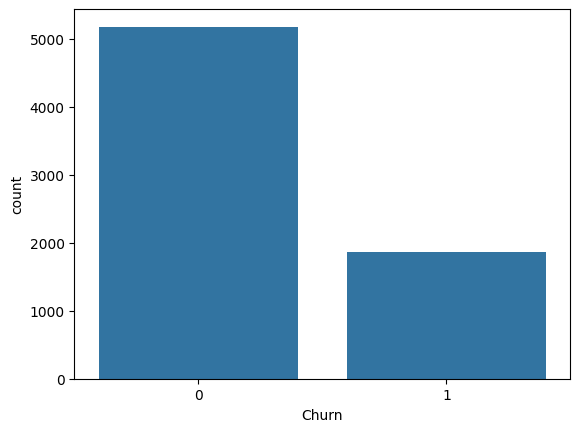

In [8]:
# Countplot
sns.countplot(x='Churn', data=df)
plt.show()

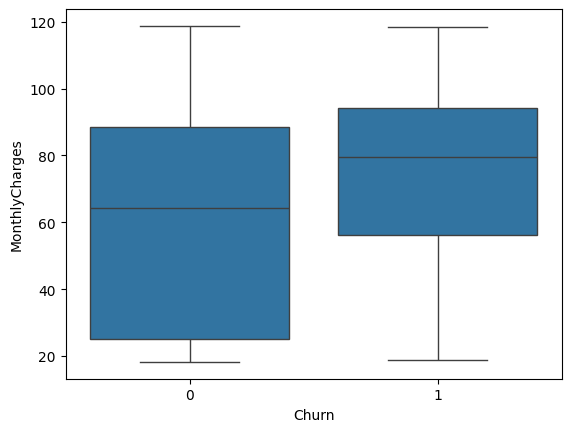

In [9]:
# Boxplot
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

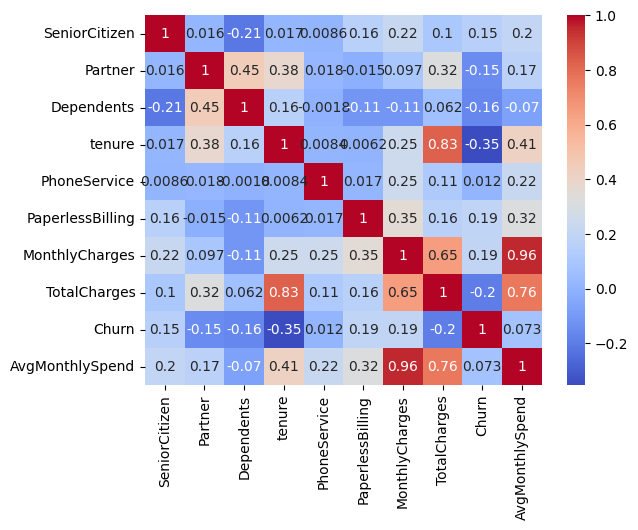

In [10]:
# Take only numeric columns
num_df = df.select_dtypes(include=['int64','float64'])

# Heatmap
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.show()